In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2

print("✅ All libraries imported successfully!")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)



✅ All libraries imported successfully!
NumPy: 2.0.2
Pandas: 2.2.2
TensorFlow: 2.19.0
OpenCV: 4.12.0


In [6]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import random

print("✅ All imports working fine!")


✅ All imports working fine!


In [7]:
from google.colab import files
uploaded = files.upload()  # ⬆️ select traffic_sign.csv when prompted

import pandas as pd
label_data = pd.read_csv("traffic_sign.csv")


Saving traffic_sign.csv to traffic_sign (1).csv


In [8]:
label_dict = dict(zip(label_data["ClassId"], label_data["Name"]))  # map ClassId → Name

In [10]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
img_size = 64
images, labels = [], []

import os

img_dir = "/content/drive/MyDrive/Neural Network lab/Indian Traffic Signal Classification/Indian-Traffic Sign-Dataset/Images"

for folder in os.listdir(img_dir):
    folder_path = os.path.join(img_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    # process images

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(int(folder))  # folder name is the Class ID

X = np.array(images, dtype='float32') / 255.0
y = np.array(labels)

print(f"✅ Loaded {len(X)} images across {len(np.unique(y))} classes")

✅ Loaded 13971 images across 58 classes


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=False
)
datagen.fit(X_train)

In [15]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(59, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 59)             │         7,611 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690,811 (2.64 MB)

 Trainable params: 690,811 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 78s 217ms/step - accuracy: 0.1280 - loss: 3.5484 - val_accuracy: 0.5750 - val_loss: 1.6015
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 84s 224ms/step - accuracy: 0.4698 - loss: 1.8290 - val_accuracy: 0.7309 - val_loss: 1.0045
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 77s 219ms/step - accuracy: 0.6088 - loss: 1.2774 - val_accuracy: 0.7667 - val_loss: 0.7309
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 87s 233ms/step - accuracy: 0.6876 - loss: 0.9804 - val_accuracy: 0.7961 - val_loss: 0.6436
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 76s 219ms/step - accuracy: 0.7281 - loss: 0.8297 - val_accuracy: 0.8100 - val_loss: 0.5749
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 81s 217ms/step - accuracy: 0.7662 - loss: 0.7105 - val_accuracy: 0.8340 - val_loss: 0.5331
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 81s 231ms/step - accuracy: 0.7756 - loss: 0.6566 - val_accuracy: 0.8308 - val_loss: 0.5146
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 75s 214ms/step - accuracy: 0.7954 - loss: 0

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

model.save("indian_traffic_sign_model.h5")
print("💾 Model saved as 'indian_traffic_sign_model.h5'")

88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8365 - loss: 0.4748



✅ Test Accuracy: 84.40%
💾 Model saved as 'indian_traffic_sign_model.h5'


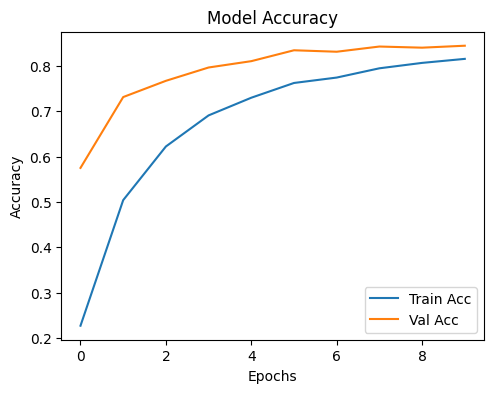

In [20]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

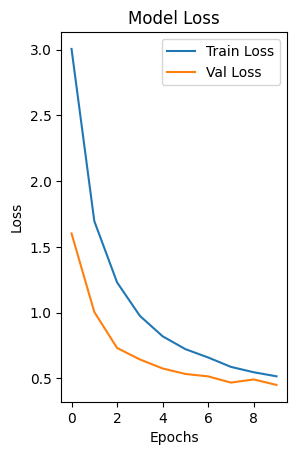

In [21]:

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step


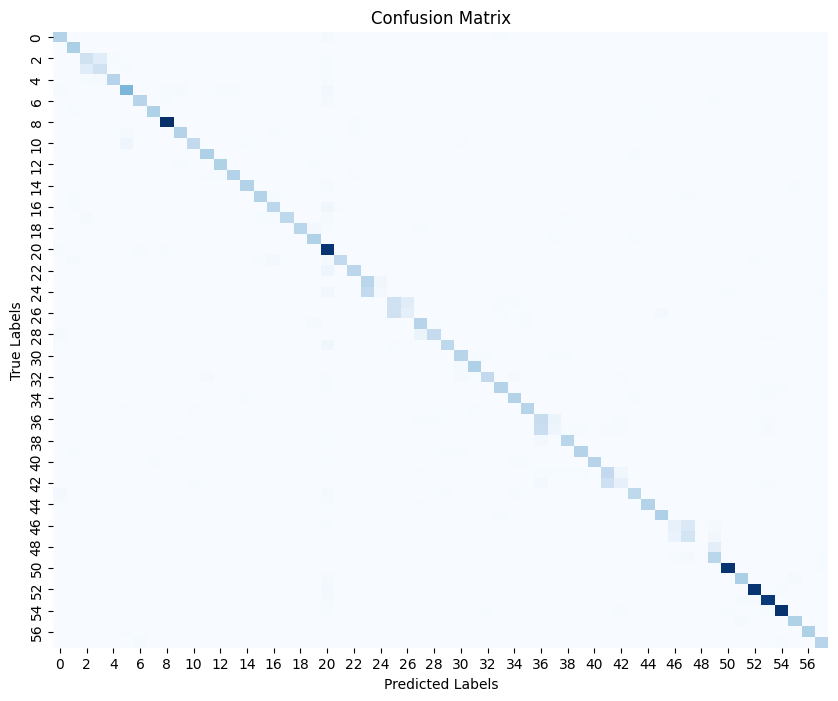

In [22]:
# ===============================
# 🔟 Confusion Matrix
# ===============================
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


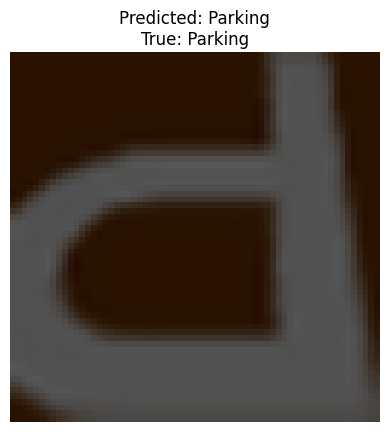

In [26]:
import random

random_index = random.randint(0, len(X_test)-1)
sample_img = X_test[random_index]
true_label = y_test[random_index]

# Predict
pred = np.argmax(model.predict(sample_img.reshape(1, img_size, img_size, 3)))
pred_name = label_dict.get(pred, "Unknown")
true_name = label_dict.get(true_label, "Unknown")

plt.imshow(sample_img)
plt.title(f"Predicted: {pred_name}\nTrue: {true_name}")
plt.axis('off')
plt.show()

In [27]:
from google.colab import files
import pandas as pd

# 📂 Step 1: Upload the CSV file from your computer
uploaded = files.upload()  # choose traffic_sign.csv when prompted

# 📘 Step 2: Load the uploaded CSV
class_df = pd.read_csv("traffic_sign.csv")

# 🗂️ Step 3: Create a dictionary mapping ClassId → Name
class_names = dict(zip(class_df["ClassId"], class_df["Name"]))

# ✅ Step 4: Verify by printing a few entries
print(list(class_names.items())[:5])


Saving traffic_sign.csv to traffic_sign (2).csv
[(0, 'Give way'), (1, 'No entry'), (2, 'One-way traffic'), (3, 'One-way traffic'), (4, 'No vehicles in both directions')]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


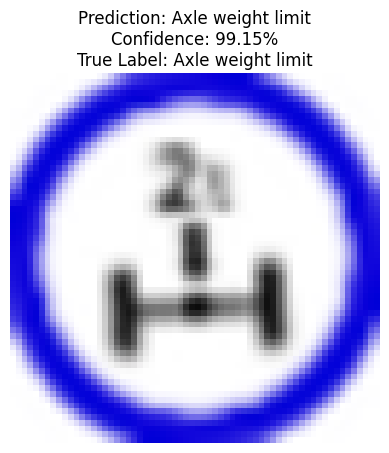

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Example: Random image from test set
idx = np.random.randint(0, len(X_test))
img = X_test[idx]
true_label = y_test[idx]
pred = model.predict(np.expand_dims(img, axis=0))
pred_label = np.argmax(pred)
confidence = np.max(pred) * 100

plt.imshow(img)
plt.title(f"Prediction: {class_names[pred_label]}\nConfidence: {confidence:.2f}%\nTrue Label: {class_names[true_label]}")
plt.axis("off")
plt.show()


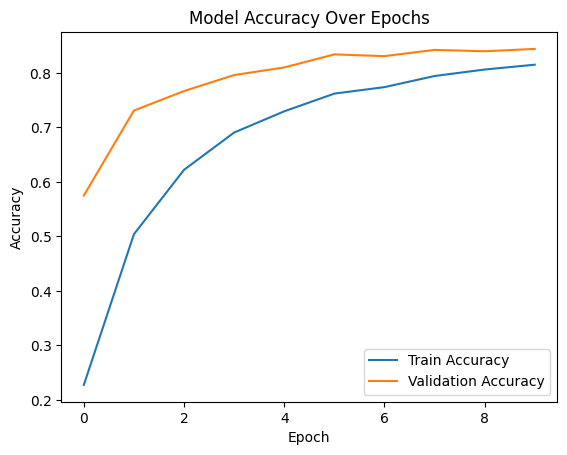

In [32]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


/tmp/ipython-input-161504783.py:13: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-161504783.py:13: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


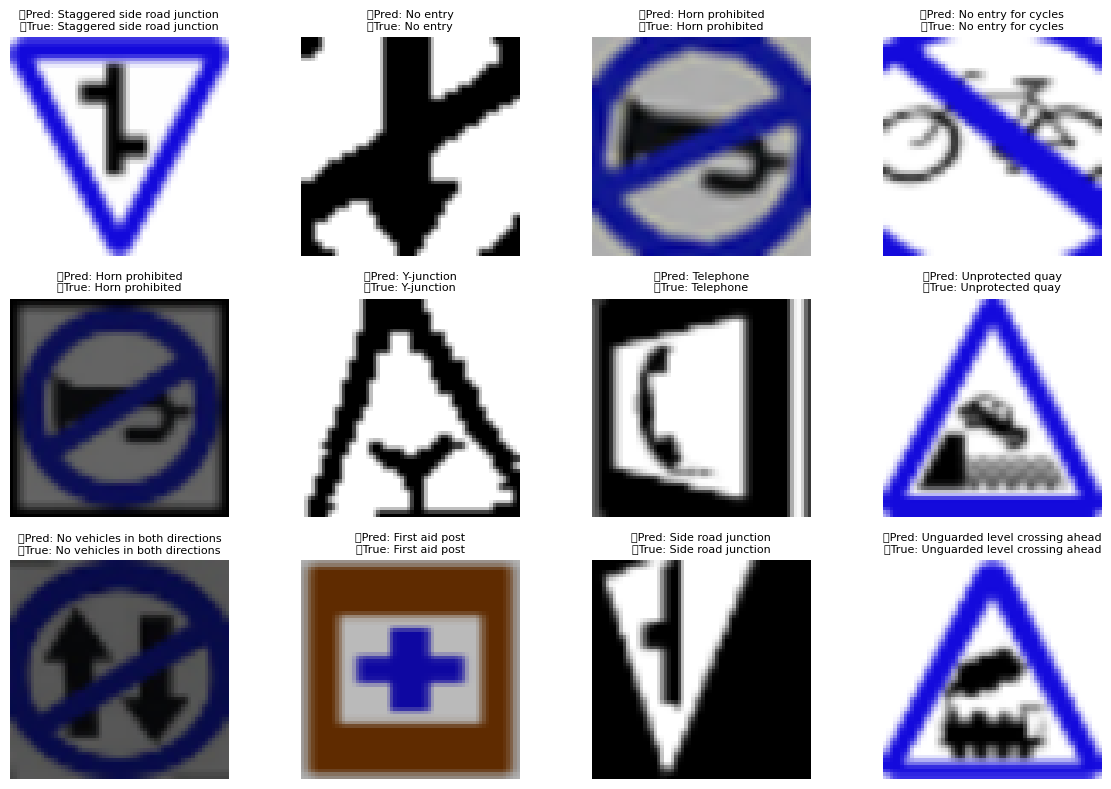

In [33]:
plt.figure(figsize=(12, 8))
for i in range(12):
    idx = np.random.randint(0, len(X_test))
    img = X_test[idx]
    true_label = y_test[idx]
    pred = model.predict(np.expand_dims(img, axis=0))
    pred_label = np.argmax(pred)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"🔹Pred: {class_names[pred_label]}\n✅True: {class_names[true_label]}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [34]:
all_labels = list(range(59))
target_names = [class_names.get(i, f"Class {i}") for i in all_labels]

print(classification_report(y_test, y_pred, labels=all_labels, target_names=target_names))


                                 precision    recall  f1-score   support

                       Give way       0.80      0.93      0.86        40
                       No entry       0.87      1.00      0.93        40
                One-way traffic       0.59      0.60      0.59        40
                One-way traffic       0.60      0.60      0.60        40
 No vehicles in both directions       0.97      0.90      0.94        40
            No entry for cycles       0.83      0.85      0.84        65
    No entry for goods vehicles       0.92      0.90      0.91        40
       No entry for pedestrians       0.97      0.95      0.96        40
     No entry for bullock carts       0.98      0.99      0.98       121
        No entry for hand carts       0.90      0.90      0.90        41
    No entry for motor vehicles       0.94      0.78      0.85        40
                   Height limit       0.93      0.97      0.95        40
                   Weight limit       0.95      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [35]:
print("✅ PROJECT SUMMARY:")
print(f"Total Images Used: {len(X)}")
print(f"Total Classes: {len(class_names)}")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print("Model: Custom CNN (3 Conv Layers + Dense Layers)")
print("Dataset: Indian Traffic Sign Dataset (59 Classes)")
print("Goal: Classify Indian traffic signs without pretrained models.")


✅ PROJECT SUMMARY:
Total Images Used: 13971
Total Classes: 59
Test Accuracy: 84.40%
Model: Custom CNN (3 Conv Layers + Dense Layers)
Dataset: Indian Traffic Sign Dataset (59 Classes)
Goal: Classify Indian traffic signs without pretrained models.
